---
## THE STRADDLE
---
A straddle is an options strategy that involves buying both a call option and a put option with the same strike price and expiration date.

**Long straddle**: A long straddle consists of buying both a call and a put option on the same underlying asset with the same strike price and expiration date. The investor bets that the asset's price will move significantly but is uncertain about the direction of the movement.
**Example**: Let's assume we buy a long straddle with a strike price of 50 €. The underlying asset's price is also 50 € at the time of purchase. The call option allows the investor to benefit from a price increase above 50 €, while the put option benefits from a price decrease below 50 €. If, at expiration, the price of the underlying asset increases to 60 €, the call will be in the money and yield 10 € per share, while the put will expire worthless. If the underlying asset's price drops to 40 €, the put will be in the money and yield 10 € per share, while the call will expire worthless.

**Short straddle**: The investor simultaneously sells a call option and a put option with the same strike price and expiration date. The objective of a short straddle is to profit from a lack of volatility or small movements in the underlying asset's price.
**Example**: Let's assume we sell a short straddle with a strike price of 50 €. The underlying asset's price is also 50 € at the time of the sale. The investor sells a call option, meaning they commit to selling the underlying asset at 50 € if the option is exercised. The investor also sells a put option, meaning they commit to buying the underlying asset at 50 € if the option is exercised. If, at expiration, the price of the underlying asset remains close to 50 €, both options expire worthless, and the investor keeps the premiums received.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

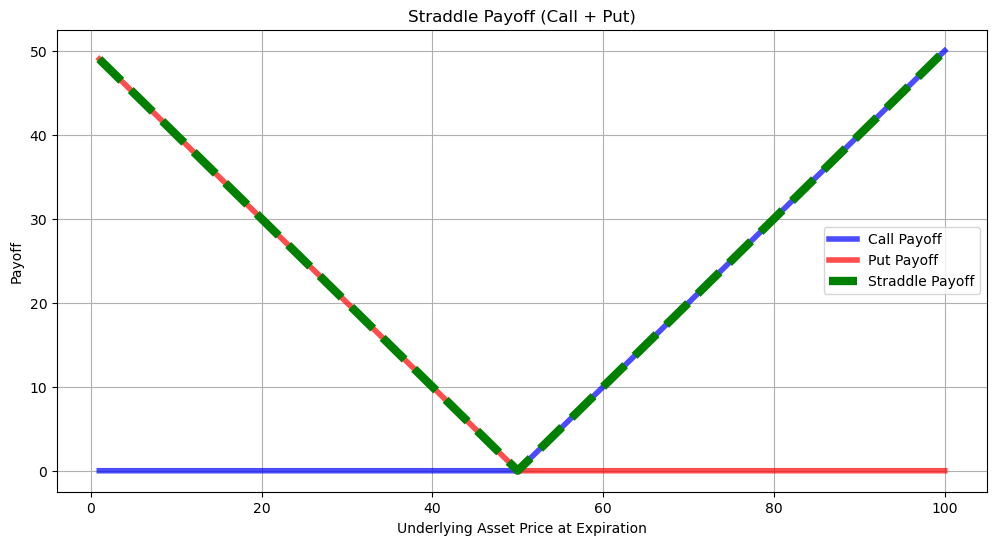

In [2]:
K = 50  # Strike price
ST = np.linspace(1, 100, 100)  # Range of the underlying asset prices at expiration
call_payoff = np.maximum(ST - K, 0)  # Payoff of the call option
put_payoff = np.maximum(K - ST, 0)  # Payoff of the put option
straddle_payoff = call_payoff + put_payoff  # Payoff of the straddle (sum of call and put payoffs)

plt.figure(figsize=(12, 6))
plt.plot(ST, call_payoff, label="Call Payoff", color='blue', alpha=0.7, linewidth=4)
plt.plot(ST, put_payoff, label="Put Payoff", color='red', alpha=0.7, linewidth=4)
plt.plot(ST, straddle_payoff, label="Straddle Payoff", color='green', linestyle='dashed', linewidth=6)

plt.title("Straddle Payoff (Call + Put)")
plt.xlabel("Underlying Asset Price at Expiration")
plt.ylabel("Payoff")
plt.legend()
plt.grid(True)
plt.show()

We considered that the call option and the put option had a price of zero. In reality, the original premium paid brings the P&L to negatives around the strike price.

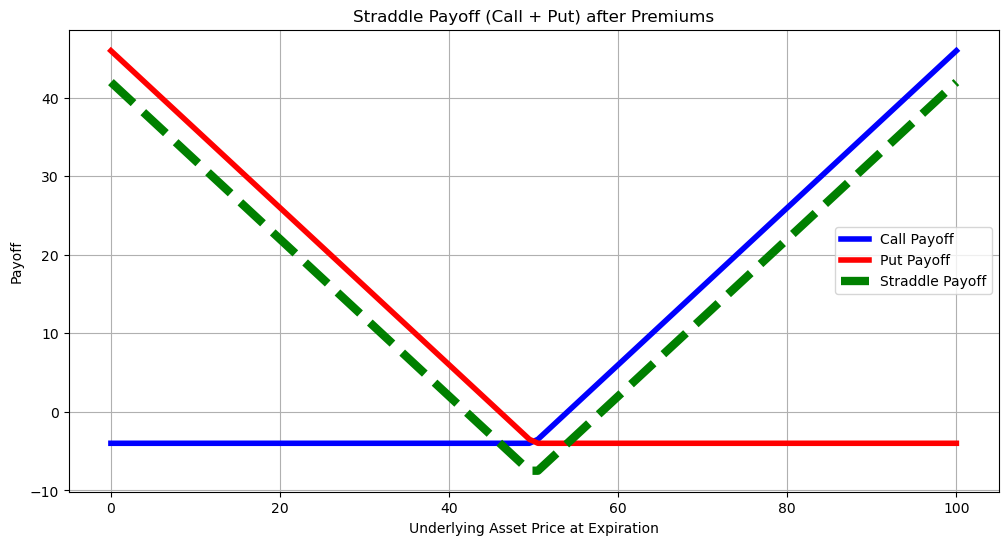

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Constants
K = 50  # Strike price
C_price = 4  # Call option price (premium paid)
P_price = 4  # Put option price (premium paid)

# Range of the underlying asset prices at expiration
ST = np.linspace(0, 100, 100)

# Payoff of the call option (at expiration)
call_payoff = np.maximum(ST - K, 0) - C_price  # Subtracting the call premium
put_payoff = np.maximum(K - ST, 0) - P_price  # Subtracting the put premium

# Payoff of the straddle (sum of call and put payoffs)
straddle_payoff = call_payoff + put_payoff

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(ST, call_payoff, label="Call Payoff", color='blue', linewidth=4)
plt.plot(ST, put_payoff, label="Put Payoff", color='red', linewidth=4)
plt.plot(ST, straddle_payoff, label="Straddle Payoff", color='green', linestyle='dashed', linewidth=6)

plt.title("Straddle Payoff (Call + Put) after Premiums")
plt.xlabel("Underlying Asset Price at Expiration")
plt.ylabel("Payoff")
plt.legend()
plt.grid(True)
plt.show()

A formula approximates the price range in which a straddle will break even, meaning where profits will start to exceed the cost of the strategy. The breakeven range is a symmetric band around the spot price. Considering that n is the number of calendar days before the option expires, and the implied volatility a percentage:

In [4]:
def breakeven_range(spot, implied_vol, n):
    factor = 4.2 * implied_vol * np.sqrt(n) / 100
    lower = spot * (1 - factor)
    upper = spot * (1 + factor)
    return lower, upper

In [7]:
spot_price = 50
implied_volatility = 10  # in %
days_to_expiry = 2
lower, upper = breakeven_range(spot_price, implied_volatility, days_to_expiry)
print(f"Breakeven range: {lower:.2f} to {upper:.2f}")

Breakeven range: 20.30 to 79.70


---
## THE DELTA

---
**Delta¨¨: The link between changes in the price of the derivative and the changes in the price of the underlying asset. When the price of the underlying asset increases, the price of the put decreases (delta is negative), while the price of the call increases (delta is positive). The delta ranges from 0 to 1 for call options and from -1 to 0 for put options.

**Example**: If a put option has a delta of -0.25 and the price of the underlying asset increases by 12 dollars, the price of the put will change by -0.25 * 12 = -3 dollar, meaning it will decrease by 3 dollars.

**Example**: If a call option has a delta of 0.50, it means that if the price of the underlying asset increases by 1 dollars, the price of the option will increase by 0.50 dollars.

A  method to calculate the delta of a European-style call or put option is the Black-Scholes model.


In [4]:
def d1(S, K, r, T, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))

def d2(S, K, r, T, sigma):
    return d1(S, K, r, T, sigma) - sigma * np.sqrt(T)

def call_delta(S, K, r, T, sigma):
    return norm.cdf(d1(S, K, r, T, sigma))

def put_delta(S, K, r, T, sigma):
    return norm.cdf(d1(S, K, r, T, sigma)) - 1

In [5]:
from scipy.stats import norm

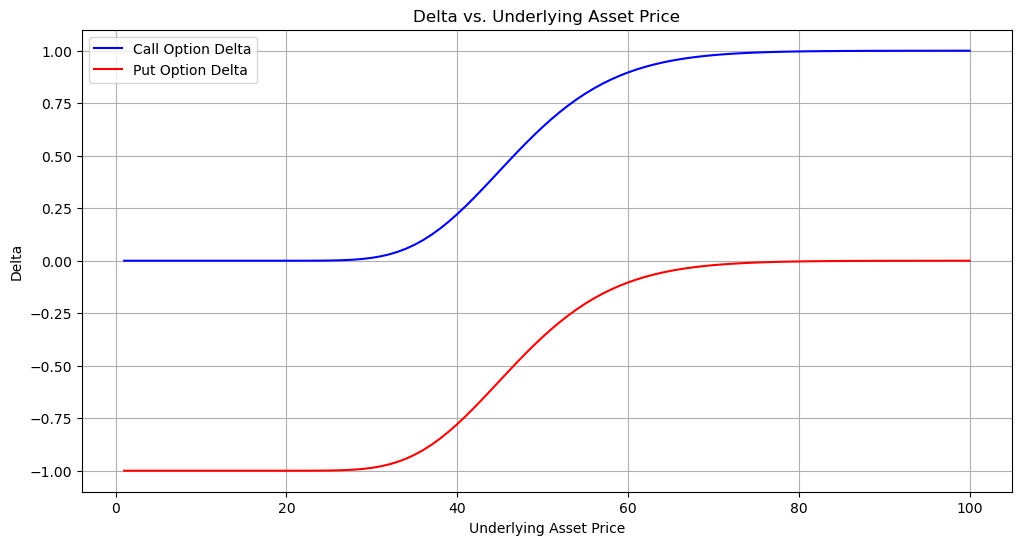

In [6]:
# Constants for Option Pricing
K = 50  # Strike Price
S0 = 50  # Initial Price of the Underlying Asset
r = 0.05  # Risk-free rate
T = 1  # Time to expiration in years
sigma = 0.2  # Volatility (20%)

# Delta vs Underlying Asset Price Plot
S_values = np.linspace(1, 100, 100)  # Price of the underlying asset
call_deltas = [call_delta(S, K, r, T, sigma) for S in S_values]
put_deltas = [put_delta(S, K, r, T, sigma) for S in S_values]

plt.figure(figsize=(12, 6))
plt.plot(S_values, call_deltas, label="Call Option Delta", color='blue')
plt.plot(S_values, put_deltas, label="Put Option Delta", color='red')
plt.title("Delta vs. Underlying Asset Price")
plt.xlabel("Underlying Asset Price")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()

The delta of an at-the-money straddle (i.e., when the price of the underlying asset is equal to the strike price of the call and put options) is initially neutral. This means the deltas of the two options cancel each other out at the beginning. However, this delta neutrality is not stable over time. As the price of the asset changes, the call and put options will react differently. 

The delta of a call option changes over time as the price of the underlying asset fluctuates.

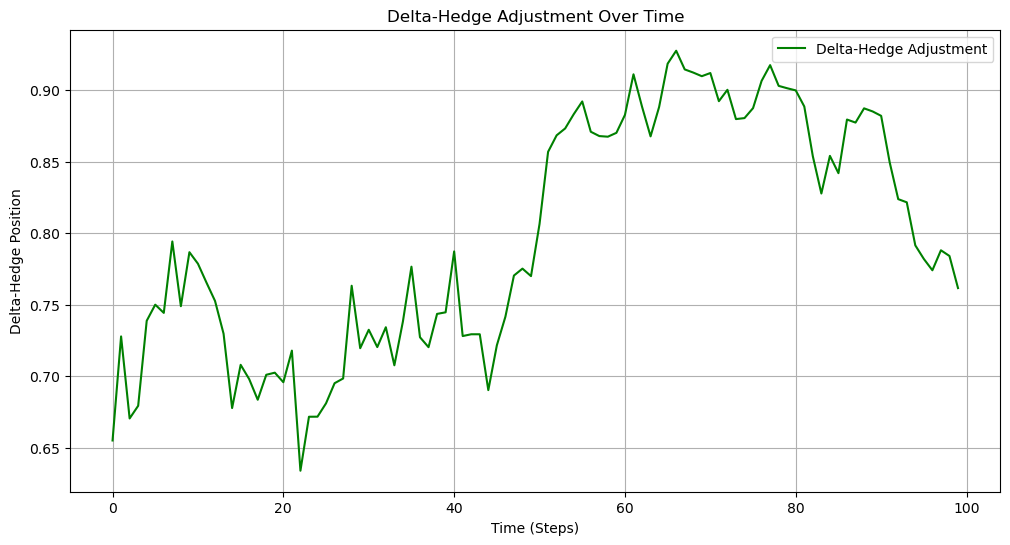

In [7]:
time_steps = 100
price_changes = np.random.normal(loc=0, scale=1, size=time_steps)  # Simulate price changes with normal distribution
prices = S0 + np.cumsum(price_changes)  # Cumulative sum of price changes
delta_hedge_over_time = []

for price in prices:
    delta_call = call_delta(price, K, r, T, sigma)
    delta_hedge_over_time.append(delta_call)

# Plotting the Delta Adjustment over Time
plt.figure(figsize=(12, 6))
plt.plot(range(time_steps), delta_hedge_over_time, label="Delta-Hedge Adjustment", color='green')
plt.title("Delta-Hedge Adjustment Over Time")
plt.xlabel("Time (Steps)")
plt.ylabel("Delta-Hedge Position")
plt.legend()
plt.grid(True)
plt.show()

---
## TO DELTA-HEDGE

---

A strategy that aims to reduce or eliminate the risk caused by changes in the price of the underlying asset. Delta-hedging involves taking another position to neutralize the delta.

**Example of delta-hedging on a put by buying the underlying asset's shares**: An investor holds a put option (with 100 shares of a company as the underlying asset). The stock drops significantly, and the trader profits from the put option. A delta-hedge is implemented to protect the profits on the put option. The put option has a delta of -0.75. The investor establishes a delta-neutral position by buying 75 shares of the underlying asset at a price of 1 euro. Proof: Suppose the shares increase by 50%, you gain 0.5 * 75 = 37.5  (profit per share * number of shares), and the 100 options change in price by 0.50 * 100 = 50 (profit per share * number of shares), so the price of the put option decreases by 0.75 * 50 = 37.5 (delta * change in asset price).

**Example of delta-hedging for a call with a put**: An investor holds a call option with a delta of 0.50 and wants to maintain a delta-neutral position. The investor could buy a put option with a delta of -0.50 to offset the positive delta.


In [8]:
import pandas as pd

Let's simulate how many call/put options are needed to hedge a position of 1000 units of the underlying asset. How many calls or puts are needed to offset the price risk

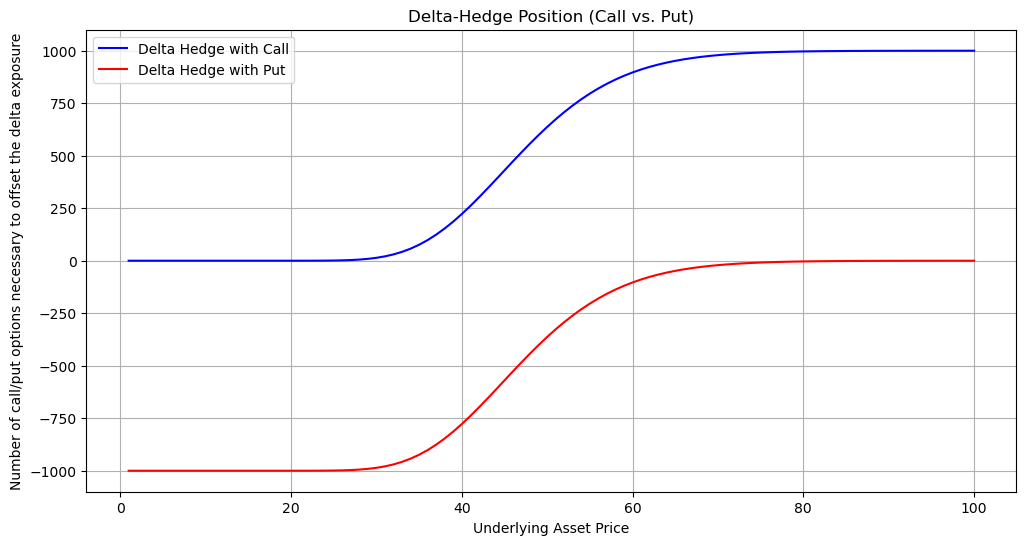

In [9]:
initial_position = 1000
position_adjustments = []

for S in S_values:
    delta_call = call_delta(S, K, r, T, sigma)
    delta_put = put_delta(S, K, r, T, sigma)
    
    # Hedging with call options (buying calls to hedge)
    delta_hedge_call = initial_position * delta_call
    
    # Hedging with put options (buying puts to hedge)
    delta_hedge_put = initial_position * delta_put
    
    position_adjustments.append([delta_hedge_call, delta_hedge_put])

position_df = pd.DataFrame(position_adjustments, columns=["Delta Hedge Call", "Delta Hedge Put"])
plt.figure(figsize=(12, 6))
plt.plot(S_values, position_df["Delta Hedge Call"], label="Delta Hedge with Call", color='blue')
plt.plot(S_values, position_df["Delta Hedge Put"], label="Delta Hedge with Put", color='red')
plt.title("Delta-Hedge Position (Call vs. Put)")
plt.xlabel("Underlying Asset Price")
plt.ylabel("Number of call/put options necessary to offset the delta exposure")
plt.legend()
plt.grid(True)
plt.show()

---
## STRADDLE GREEKS AROUND THE STRIKE PRICE

---
Each greek evolves differently around the strike price. 

In [10]:
from scipy.stats import norm

In [11]:
# Basic Parameters
K = 50       # Strike Price
r = 0.05     # Risk-free rate
T = 0.5      # Time to maturity (in years)
sigma = 0.2  # Volatility
S = np.linspace(1, 100, 100)  # Range of the underlying asset prices at expiration

# Black-Scholes Greek Formulas
def d1(S, K, r, T, sigma):
    return (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def d2(S, K, r, T, sigma):
    return d1(S, K, r, T, sigma) - sigma * np.sqrt(T)

def call_delta(S, K, r, T, sigma):
    return norm.cdf(d1(S, K, r, T, sigma))

def put_delta(S, K, r, T, sigma):
    return norm.cdf(d1(S, K, r, T, sigma)) - 1

def gamma(S, K, r, T, sigma):
    return norm.pdf(d1(S, K, r, T, sigma)) / (S * sigma * np.sqrt(T))

def vega(S, K, r, T, sigma):
    return S * norm.pdf(d1(S, K, r, T, sigma)) * np.sqrt(T)

def call_theta(S, K, r, T, sigma):
    d1_val = d1(S, K, r, T, sigma)
    d2_val = d2(S, K, r, T, sigma)
    term1 = -S * norm.pdf(d1_val) * sigma / (2 * np.sqrt(T))
    term2 = -r * K * np.exp(-r*T) * norm.cdf(d2_val)
    return term1 + term2

def put_theta(S, K, r, T, sigma):
    d1_val = d1(S, K, r, T, sigma)
    d2_val = d2(S, K, r, T, sigma)
    term1 = -S * norm.pdf(d1_val) * sigma / (2 * np.sqrt(T))
    term2 = r * K * np.exp(-r*T) * norm.cdf(-d2_val)
    return term1 + term2

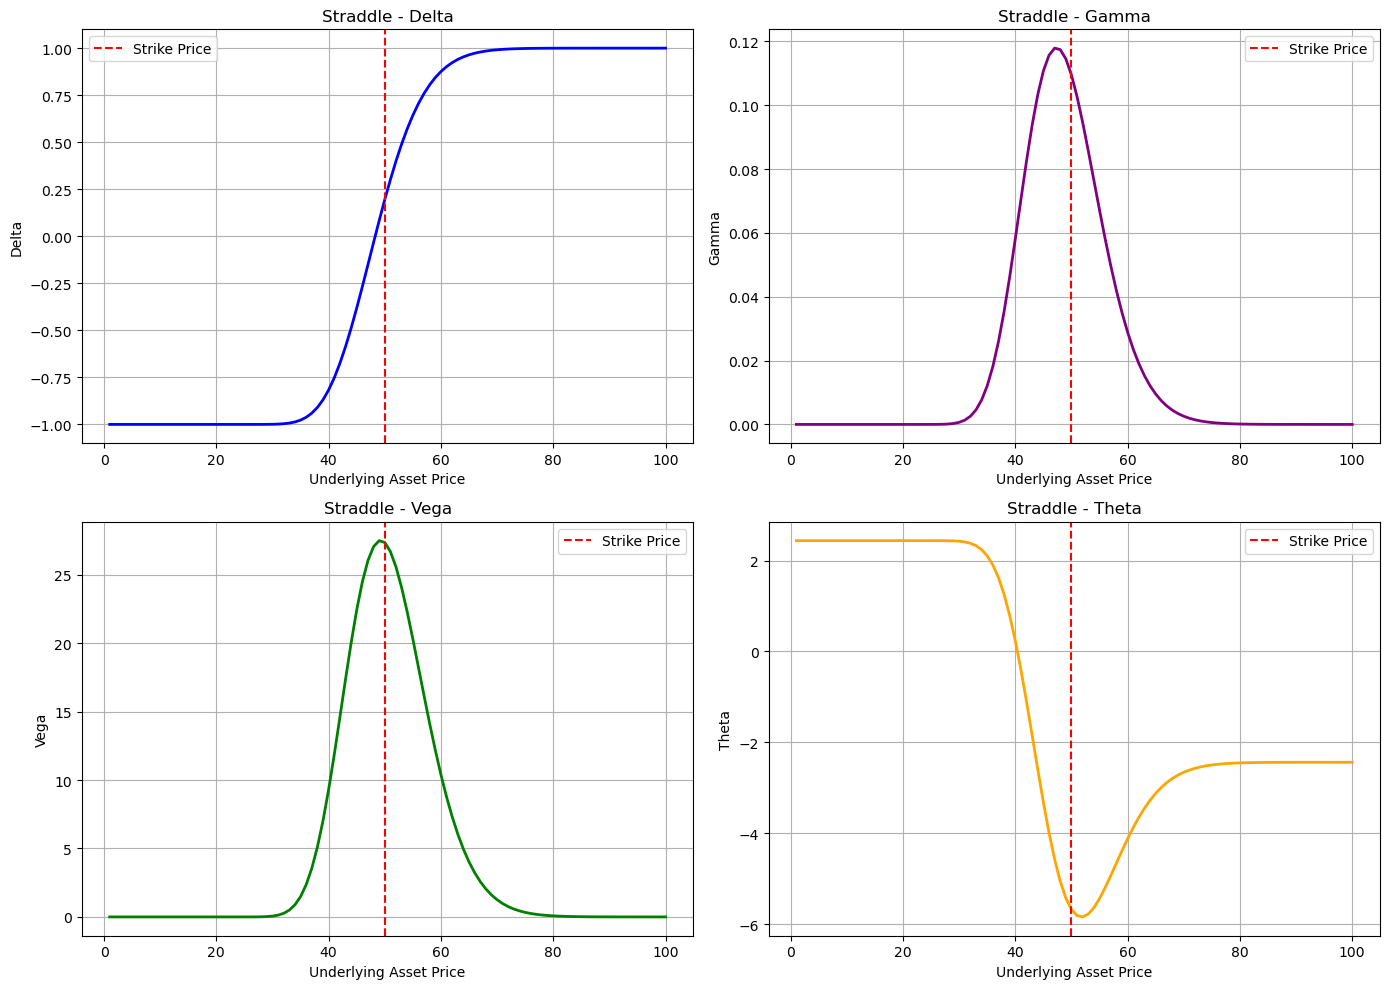

In [12]:
# Straddle Greeks
straddle_delta = call_delta(S, K, r, T, sigma) + put_delta(S, K, r, T, sigma)
straddle_gamma = 2 * gamma(S, K, r, T, sigma)  # Same for call and put
straddle_vega = 2 * vega(S, K, r, T, sigma) # Same for call and put
straddle_theta = call_theta(S, K, r, T, sigma) + put_theta(S, K, r, T, sigma)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
greeks = [straddle_delta, straddle_gamma, straddle_vega, straddle_theta]
titles = ['Delta', 'Gamma', 'Vega', 'Theta']
colors = ['blue', 'purple', 'green', 'orange']

for ax, greek, title, color in zip(axs.flat, greeks, titles, colors):
    ax.plot(S, greek, color=color, lw=2)
    ax.axvline(K, color='red', linestyle='--', label="Strike Price")
    ax.set_title(f"Straddle - {title}")
    ax.set_xlabel("Underlying Asset Price")
    ax.set_ylabel(title)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

**DELTA**: The straddle’s delta is zero at ATM, but increases in magnitude away from the strike. The further S is from the strike price, the closer straddle price is from moving nearly dollar-for-dollar with the stock.

**GAMMA**: The straddle’s gamma peaks at ATM. The delta of the straddle changes the most rapidly near the strike. So if you're holding a straddle and the underlying price is close to the strike, you’ll experience big swings in delta, and therefore in P&L from even small market movements.

**VEGA**: The straddle’s Vega peaks at ATM. The option is most uncertain around the strike, small changes in volatility greatly affect the probability of finishing ITM if S is close to the strike price. Deep ITM or OTM options are less sensitive. They are already likely or unlikely to end up ITM, so volatility changes don’t affect their value much.

**THETA**: The straddle’s theta is lowest ATM. Each day that passes without movement,the chance of making money fades so time decay hits hardest when you’re at the strike.